Clustering With K Means - Python Tutorial

In [1]:
from collections import Counter
import ast
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
def count_items(value):
    if pd.isna(value):
        return 0

    text = str(value).strip()
    if text in ('', '[]', 'nan', 'None'):
        return 0

    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, (list, tuple, set, dict)):
            return len(parsed)
    except (ValueError, SyntaxError):
        pass

    cleaned = text.strip('[]')
    if not cleaned:
        return 0

    return len([item for item in cleaned.split(',') if item.strip()])

def word_count(value):
    if pd.isna(value):
        return 0
    text = str(value).strip()
    if text in ('', 'nan', 'None'):
        return 0
    return len([word for word in text.split() if word.strip()])

def avg_token_length(value):
    if pd.isna(value):
        return 0
    tokens = [token for token in str(value).split() if token.strip()]
    if not tokens:
        return 0
    return sum(len(token) for token in tokens) / len(tokens)

venue_counter = Counter()
for chunk in pd.read_csv('dblp-v10.csv', usecols=['venue'], chunksize=50000):
    venues = chunk['venue'].dropna().astype(str).str.strip()
    venues = venues[venues.ne('')]
    venue_counter.update(venues)

top_venues = [venue for venue, _ in venue_counter.most_common(3)]
top_venues

['international conference on acoustics, speech, and signal processing',
 'international conference on robotics and automation',
 'Lecture Notes in Computer Science']

In [3]:
df = pd.read_csv('dblp-v10.csv', nrows=5)
df.head()

,abstract,authors,n_citation,references,title,venue,year,id
0,"In this paper, a robust 3D triangular mesh wat...","['S. Ben Jabra', 'Ezzeddine Zagrouba']",50,"['09cb2d7d-47d1-4a85-bfe5-faa8221e644b', '10aa...",A new approach of 3D watermarking based on ima...,international symposium on computers and commu...,2008,4ab3735c-80f1-472d-b953-fa0557fed28b
1,We studied an autoassociative neural network w...,"['Joaquín J. Torres', 'Jesús M. Cortés', 'Joaq...",50,"['4017c9d2-9845-4ad2-ad5b-ba65523727c5', 'b118...",Attractor neural networks with activity-depend...,Neurocomputing,2007,4ab39729-af77-46f7-a662-16984fb9c1db
2,It is well-known that Sturmian sequences are t...,"['Genevi eve Paquin', 'Laurent Vuillon']",50,"['1c655ee2-067d-4bc4-b8cc-bc779e9a7f10', '2e4e...",A characterization of balanced episturmian seq...,Electronic Journal of Combinatorics,2007,4ab3a4cf-1d96-4ce5-ab6f-b3e19fc260de
3,One of the fundamental challenges of recognizi...,"['Yaser Sheikh', 'Mumtaz Sheikh', 'Mubarak Shah']",221,"['056116c1-9e7a-4f9b-a918-44eb199e67d6', '05ac...",Exploring the space of a human action,international conference on computer vision,2005,4ab3a98c-3620-47ec-b578-884ecf4a6206
4,This paper generalizes previous optimal upper ...,"['Efraim Laksman', 'Håkan Lennerstad', 'Magnus...",0,"['01a765b8-0cb3-495c-996f-29c36756b435', '5dbc...",Generalized upper bounds on the minimum distan...,Ima Journal of Mathematical Control and Inform...,2015,4ab3b585-82b4-4207-91dd-b6bce7e27c4e


In [4]:
chunks = []
for chunk in pd.read_csv('dblp-v10.csv', usecols=['abstract', 'authors', 'n_citation', 'references', 'title', 'venue', 'year', 'id'], chunksize=50000, engine='python'):
    chunk = chunk.drop_duplicates().copy()
    text_columns = ['abstract', 'authors', 'references', 'title', 'venue', 'id']
    chunk[text_columns] = chunk[text_columns].fillna('')
    chunk['year'] = pd.to_numeric(chunk['year'], errors='coerce')
    chunk['n_citation'] = pd.to_numeric(chunk['n_citation'], errors='coerce')
    chunk = chunk.dropna(subset=['year', 'n_citation']).copy()
    chunk['year'] = chunk['year'].astype(int)
    chunk = chunk[chunk['venue'].isin(top_venues)].copy()
    chunk['reference_count'] = chunk['references'].apply(count_items)
    chunk['author_count'] = chunk['authors'].apply(count_items)
    chunk['title_char_count'] = chunk['title'].str.len()
    chunk['abstract_char_count'] = chunk['abstract'].str.len()
    chunk['title_word_count'] = chunk['title'].apply(word_count)
    chunk['abstract_word_count'] = chunk['abstract'].apply(word_count)
    chunk['venue_word_count'] = chunk['venue'].apply(word_count)
    chunk['venue_char_count'] = chunk['venue'].str.len()
    chunk['id_length'] = chunk['id'].str.len()
    chunk['avg_title_token_length'] = chunk['title'].apply(avg_token_length)
    chunk['avg_abstract_token_length'] = chunk['abstract'].apply(avg_token_length)
    chunk['avg_venue_token_length'] = chunk['venue'].apply(avg_token_length)
    if not chunk.empty:
        chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True).drop_duplicates().copy()
print('Cleaned rows:', len(df))
print('Duplicate rows:', df.duplicated().sum())
print('Missing values per column:')
print(df.isna().sum())
assert df.isna().sum().sum() == 0
assert df.duplicated().sum() == 0
df.head()

Cleaned rows: 29863
Duplicate rows: 0
Missing values per column:
abstract                     0
authors                      0
n_citation                   0
references                   0
title                        0
venue                        0
year                         0
id                           0
reference_count              0
author_count                 0
title_char_count             0
abstract_char_count          0
title_word_count             0
abstract_word_count          0
venue_word_count             0
venue_char_count             0
id_length                    0
avg_title_token_length       0
avg_abstract_token_length    0
avg_venue_token_length       0
dtype: int64


,abstract,authors,n_citation,references,title,venue,year,id,reference_count,author_count,title_char_count,abstract_char_count,title_word_count,abstract_word_count,venue_word_count,venue_char_count,id_length,avg_title_token_length,avg_abstract_token_length,avg_venue_token_length
0,We first discuss some general aspects of micro...,"['Maria Chiara Carrozza', 'Paolo Dario', 'Aria...",50,"['5ecd70e1-7ccc-4b2f-ac09-b91953cca5cd', '7fa7...",Manipulating biological and mechanical micro-o...,international conference on robotics and autom...,1998,4ab4244d-fb3e-49a3-b125-367df3d8e6ba,4,4,93,667,8,89,6,51,36,10.750000,6.505618,7.666667
1,A novel algorithm is presented for determining...,"['Tieniu Tan', 'Keith D. Baker', 'Geoffrey D. ...",50,"['0eb65a75-b5e8-4ff3-8e88-0b9d54708e36', '12f9...",Model-independent recovery of object orientations,international conference on robotics and autom...,1997,4abbff15-099d-4f55-b404-a99f4400984d,11,3,49,395,5,60,6,51,36,9.000000,5.600000,7.666667
2,This paper addresses the architecture optimiza...,"['Damien Chablat', 'Philippe Wenger']",327,"['14b3f8bf-2183-4a12-a435-97ae5b30e6b4', '173c...",Architecture optimization of a 3-DOF translati...,international conference on robotics and autom...,2003,4abe8dc6-b11f-4378-92d7-d301663832c9,9,2,112,725,13,98,6,51,36,7.692308,6.408163,7.666667
3,"In this paper, we use information retrieval (I...","['Xiaoqiang Xiao', 'Jasha Droppo', 'Alex Acero']",50,"['0252db2f-8ba1-47a1-b115-d90cf0a1d541', '0e29...",Information retrieval methods for automatic sp...,"international conference on acoustics, speech,...",2010,4abf915d-19a6-46c7-ba77-04b47cc740f8,10,3,62,785,7,121,8,68,36,8.000000,5.495868,7.625000
4,This paper investigates the use of an infinity...,"['Arati S. Deo', 'Ian D. Walker']",108,"['06a14ec6-190b-4f85-b000-ef02598e2d76', '17ab...",Minimum effort inverse kinematics for redundan...,international conference on robotics and autom...,1997,4ac1a39a-553a-489a-9479-301391d63cb8,5,2,60,981,7,143,6,51,36,7.714286,5.867133,7.666667


**DBLP venue vs numeric feature preview**

Text(0, 0.5, 'n_citation')

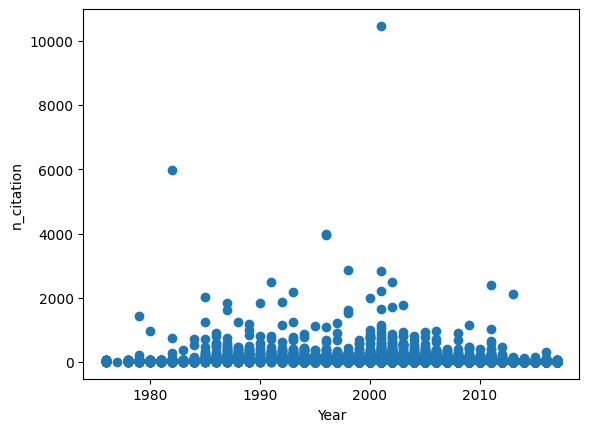

In [5]:
plt.scatter(df['year'], df['n_citation'])
plt.xlabel('Year')
plt.ylabel('n_citation')

In [6]:
le_venue = pd.Categorical(df['venue'], categories=top_venues)
df['venue_code'] = le_venue.codes

scaler = MinMaxScaler()
numeric_cols = ['year', 'n_citation', 'reference_count', 'author_count', 'title_char_count', 'abstract_char_count', 'title_word_count', 'abstract_word_count', 'venue_char_count', 'venue_word_count', 'id_length', 'avg_title_token_length', 'avg_abstract_token_length', 'avg_venue_token_length']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df.head()

,abstract,authors,n_citation,references,title,venue,year,id,reference_count,author_count,...,abstract_char_count,title_word_count,abstract_word_count,venue_word_count,venue_char_count,id_length,avg_title_token_length,avg_abstract_token_length,avg_venue_token_length,venue_code
0,We first discuss some general aspects of micro...,"['Maria Chiara Carrozza', 'Paolo Dario', 'Aria...",0.004777,"['5ecd70e1-7ccc-4b2f-ac09-b91953cca5cd', '7fa7...",Manipulating biological and mechanical micro-o...,international conference on robotics and autom...,0.536585,4ab4244d-fb3e-49a3-b125-367df3d8e6ba,0.029630,0.136364,...,0.192219,0.250000,0.156415,0.333333,0.514286,0.0,0.606250,0.453880,1.000000,1
1,A novel algorithm is presented for determining...,"['Tieniu Tan', 'Keith D. Baker', 'Geoffrey D. ...",0.004777,"['0eb65a75-b5e8-4ff3-8e88-0b9d54708e36', '12f9...",Model-independent recovery of object orientations,international conference on robotics and autom...,0.512195,4abbff15-099d-4f55-b404-a99f4400984d,0.081481,0.090909,...,0.113833,0.142857,0.105448,0.333333,0.514286,0.0,0.475000,0.390698,1.000000,1
2,This paper addresses the architecture optimiza...,"['Damien Chablat', 'Philippe Wenger']",0.031241,"['14b3f8bf-2183-4a12-a435-97ae5b30e6b4', '173c...",Architecture optimization of a 3-DOF translati...,international conference on robotics and autom...,0.658537,4abe8dc6-b11f-4378-92d7-d301663832c9,0.066667,0.045455,...,0.208934,0.428571,0.172232,0.333333,0.514286,0.0,0.376923,0.447081,1.000000,1
3,"In this paper, we use information retrieval (I...","['Xiaoqiang Xiao', 'Jasha Droppo', 'Alex Acero']",0.004777,"['0252db2f-8ba1-47a1-b115-d90cf0a1d541', '0e29...",Information retrieval methods for automatic sp...,"international conference on acoustics, speech,...",0.829268,4abf915d-19a6-46c7-ba77-04b47cc740f8,0.074074,0.090909,...,0.226225,0.214286,0.212654,1.000000,1.000000,0.0,0.400000,0.383433,0.977679,0
4,This paper investigates the use of an infinity...,"['Arati S. Deo', 'Ian D. Walker']",0.010318,"['06a14ec6-190b-4f85-b000-ef02598e2d76', '17ab...",Minimum effort inverse kinematics for redundan...,international conference on robotics and autom...,0.512195,4ac1a39a-553a-489a-9479-301391d63cb8,0.037037,0.045455,...,0.282709,0.214286,0.251318,0.333333,0.514286,0.0,0.378571,0.409335,1.000000,1


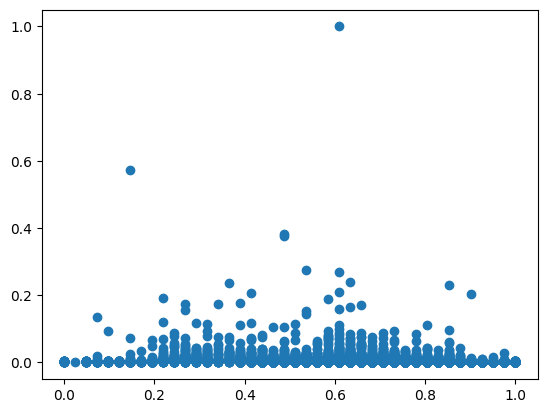

In [7]:
plt.scatter(df['year'], df['n_citation'])

**Train Using K Means**

In [8]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
y_predicted = km.fit_predict(df[['year', 'n_citation', 'reference_count', 'author_count', 'title_char_count', 'abstract_char_count']])
y_predicted

array([2, 2, 1, ..., 1, 0, 1])

In [9]:
df['cluster'] = y_predicted
df.head()

,abstract,authors,n_citation,references,title,venue,year,id,reference_count,author_count,...,title_word_count,abstract_word_count,venue_word_count,venue_char_count,id_length,avg_title_token_length,avg_abstract_token_length,avg_venue_token_length,venue_code,cluster
0,We first discuss some general aspects of micro...,"['Maria Chiara Carrozza', 'Paolo Dario', 'Aria...",0.004777,"['5ecd70e1-7ccc-4b2f-ac09-b91953cca5cd', '7fa7...",Manipulating biological and mechanical micro-o...,international conference on robotics and autom...,0.536585,4ab4244d-fb3e-49a3-b125-367df3d8e6ba,0.029630,0.136364,...,0.250000,0.156415,0.333333,0.514286,0.0,0.606250,0.453880,1.000000,1,2
1,A novel algorithm is presented for determining...,"['Tieniu Tan', 'Keith D. Baker', 'Geoffrey D. ...",0.004777,"['0eb65a75-b5e8-4ff3-8e88-0b9d54708e36', '12f9...",Model-independent recovery of object orientations,international conference on robotics and autom...,0.512195,4abbff15-099d-4f55-b404-a99f4400984d,0.081481,0.090909,...,0.142857,0.105448,0.333333,0.514286,0.0,0.475000,0.390698,1.000000,1,2
2,This paper addresses the architecture optimiza...,"['Damien Chablat', 'Philippe Wenger']",0.031241,"['14b3f8bf-2183-4a12-a435-97ae5b30e6b4', '173c...",Architecture optimization of a 3-DOF translati...,international conference on robotics and autom...,0.658537,4abe8dc6-b11f-4378-92d7-d301663832c9,0.066667,0.045455,...,0.428571,0.172232,0.333333,0.514286,0.0,0.376923,0.447081,1.000000,1,1
3,"In this paper, we use information retrieval (I...","['Xiaoqiang Xiao', 'Jasha Droppo', 'Alex Acero']",0.004777,"['0252db2f-8ba1-47a1-b115-d90cf0a1d541', '0e29...",Information retrieval methods for automatic sp...,"international conference on acoustics, speech,...",0.829268,4abf915d-19a6-46c7-ba77-04b47cc740f8,0.074074,0.090909,...,0.214286,0.212654,1.000000,1.000000,0.0,0.400000,0.383433,0.977679,0,1
4,This paper investigates the use of an infinity...,"['Arati S. Deo', 'Ian D. Walker']",0.010318,"['06a14ec6-190b-4f85-b000-ef02598e2d76', '17ab...",Minimum effort inverse kinematics for redundan...,international conference on robotics and autom...,0.512195,4ac1a39a-553a-489a-9479-301391d63cb8,0.037037,0.045455,...,0.214286,0.251318,0.333333,0.514286,0.0,0.378571,0.409335,1.000000,1,2


In [10]:
km.cluster_centers_

array([[0.69465284, 0.0035314 , 0.03195889, 0.08380702, 0.26251618,
        0.22275299],
       [0.8365872 , 0.002522  , 0.0587916 , 0.10903283, 0.40265998,
        0.25268547],
       [0.41051541, 0.00621415, 0.02855186, 0.06520293, 0.30946076,
        0.21902708]])

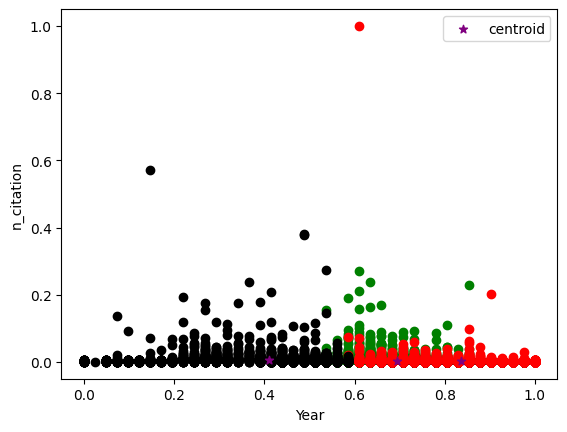

In [11]:
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]
plt.scatter(df1['year'], df1['n_citation'], color='green')
plt.scatter(df2['year'], df2['n_citation'], color='red')
plt.scatter(df3['year'], df3['n_citation'], color='black')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], color='purple', marker='*', label='centroid')
plt.xlabel('Year')
plt.ylabel('n_citation')
plt.legend()

Elbow Plot

In [12]:
sse = []
k_rng = range(1, 10)
for k in k_rng:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df[['year', 'n_citation', 'reference_count', 'author_count', 'title_char_count', 'abstract_char_count']])
    sse.append(km.inertia_)

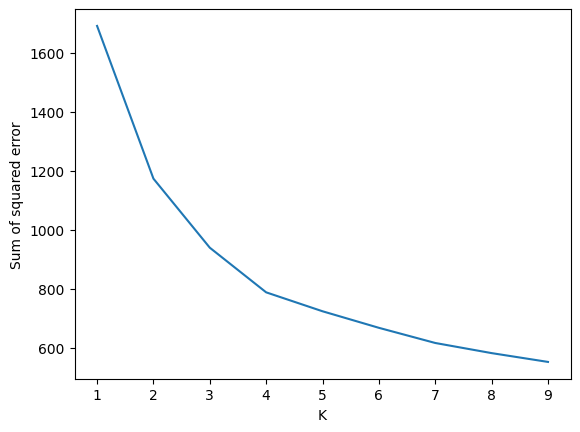

In [13]:
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng, sse)

Alternative clustering using text-based numeric features

In [14]:
alt_features = df[['reference_count', 'author_count', 'title_word_count', 'abstract_word_count', 'venue_word_count', 'id_length']].copy()
alt_features.head()

,reference_count,author_count,title_word_count,abstract_word_count,venue_word_count,id_length
0,0.029630,0.136364,0.250000,0.156415,0.333333,0.0
1,0.081481,0.090909,0.142857,0.105448,0.333333,0.0
2,0.066667,0.045455,0.428571,0.172232,0.333333,0.0
3,0.074074,0.090909,0.214286,0.212654,1.000000,0.0
4,0.037037,0.045455,0.214286,0.251318,0.333333,0.0


In [15]:
alt_scaler = MinMaxScaler()
alt_features_scaled = alt_scaler.fit_transform(alt_features)
alt_features_scaled[:5]

array([[0.02962963, 0.13636364, 0.25      , 0.15641476, 0.33333333,
        0.        ],
       [0.08148148, 0.09090909, 0.14285714, 0.10544815, 0.33333333,
        0.        ],
       [0.06666667, 0.04545455, 0.42857143, 0.17223199, 0.33333333,
        0.        ],
       [0.07407407, 0.09090909, 0.21428571, 0.21265378, 1.        ,
        0.        ],
       [0.03703704, 0.04545455, 0.21428571, 0.2513181 , 0.33333333,
        0.        ]])

In [16]:
km_alt = KMeans(n_clusters=3, random_state=42, n_init=10)
alt_clusters = km_alt.fit_predict(alt_features_scaled)
alt_clusters

array([2, 2, 2, ..., 1, 1, 2])

In [17]:
df['alt_cluster'] = alt_clusters
df.head()

,abstract,authors,n_citation,references,title,venue,year,id,reference_count,author_count,...,abstract_word_count,venue_word_count,venue_char_count,id_length,avg_title_token_length,avg_abstract_token_length,avg_venue_token_length,venue_code,cluster,alt_cluster
0,We first discuss some general aspects of micro...,"['Maria Chiara Carrozza', 'Paolo Dario', 'Aria...",0.004777,"['5ecd70e1-7ccc-4b2f-ac09-b91953cca5cd', '7fa7...",Manipulating biological and mechanical micro-o...,international conference on robotics and autom...,0.536585,4ab4244d-fb3e-49a3-b125-367df3d8e6ba,0.029630,0.136364,...,0.156415,0.333333,0.514286,0.0,0.606250,0.453880,1.000000,1,2,2
1,A novel algorithm is presented for determining...,"['Tieniu Tan', 'Keith D. Baker', 'Geoffrey D. ...",0.004777,"['0eb65a75-b5e8-4ff3-8e88-0b9d54708e36', '12f9...",Model-independent recovery of object orientations,international conference on robotics and autom...,0.512195,4abbff15-099d-4f55-b404-a99f4400984d,0.081481,0.090909,...,0.105448,0.333333,0.514286,0.0,0.475000,0.390698,1.000000,1,2,2
2,This paper addresses the architecture optimiza...,"['Damien Chablat', 'Philippe Wenger']",0.031241,"['14b3f8bf-2183-4a12-a435-97ae5b30e6b4', '173c...",Architecture optimization of a 3-DOF translati...,international conference on robotics and autom...,0.658537,4abe8dc6-b11f-4378-92d7-d301663832c9,0.066667,0.045455,...,0.172232,0.333333,0.514286,0.0,0.376923,0.447081,1.000000,1,1,2
3,"In this paper, we use information retrieval (I...","['Xiaoqiang Xiao', 'Jasha Droppo', 'Alex Acero']",0.004777,"['0252db2f-8ba1-47a1-b115-d90cf0a1d541', '0e29...",Information retrieval methods for automatic sp...,"international conference on acoustics, speech,...",0.829268,4abf915d-19a6-46c7-ba77-04b47cc740f8,0.074074,0.090909,...,0.212654,1.000000,1.000000,0.0,0.400000,0.383433,0.977679,0,1,0
4,This paper investigates the use of an infinity...,"['Arati S. Deo', 'Ian D. Walker']",0.010318,"['06a14ec6-190b-4f85-b000-ef02598e2d76', '17ab...",Minimum effort inverse kinematics for redundan...,international conference on robotics and autom...,0.512195,4ac1a39a-553a-489a-9479-301391d63cb8,0.037037,0.045455,...,0.251318,0.333333,0.514286,0.0,0.378571,0.409335,1.000000,1,2,2


In [18]:
km_alt.cluster_centers_

array([[4.37332532e-02, 8.80547360e-02, 3.05660195e-01, 2.09042292e-01,
        1.00000000e+00, 0.00000000e+00],
       [1.91765736e-02, 8.53034365e-02, 2.68126980e-01, 2.00323224e-01,
        5.44009282e-15, 0.00000000e+00],
       [5.58183018e-02, 9.54522322e-02, 3.09723737e-01, 2.24014096e-01,
        3.33333333e-01, 0.00000000e+00]])

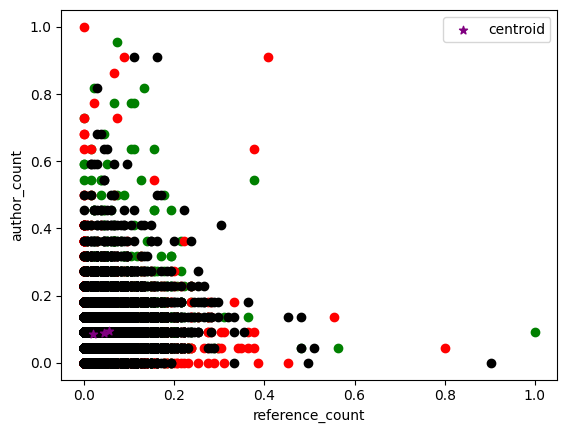

In [19]:
alt_df1 = df[df.alt_cluster==0]
alt_df2 = df[df.alt_cluster==1]
alt_df3 = df[df.alt_cluster==2]
plt.scatter(alt_df1['reference_count'], alt_df1['author_count'], color='green')
plt.scatter(alt_df2['reference_count'], alt_df2['author_count'], color='red')
plt.scatter(alt_df3['reference_count'], alt_df3['author_count'], color='black')
plt.scatter(km_alt.cluster_centers_[:,0], km_alt.cluster_centers_[:,1], color='purple', marker='*', label='centroid')
plt.xlabel('reference_count')
plt.ylabel('author_count')
plt.legend()

In [20]:
alt_sse = []
alt_k_rng = range(1, 10)
for k in alt_k_rng:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(alt_features_scaled)
    alt_sse.append(km.inertia_)

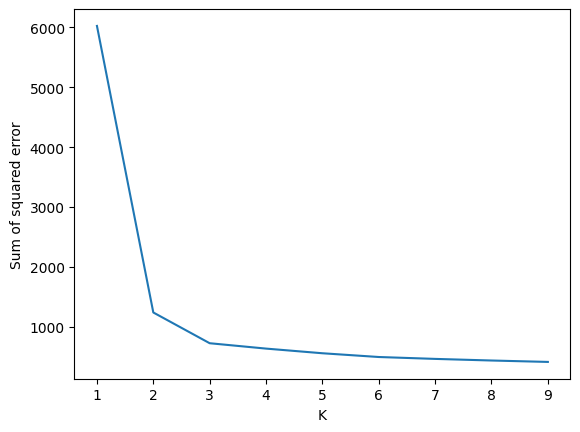

In [21]:
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(alt_k_rng, alt_sse)

In [22]:
pd.crosstab(df['cluster'], df['alt_cluster'])

alt_cluster,0,1,2
cluster,,,
0,4490,6461,3381
1,5690,1406,3511
2,1652,339,2933


In [23]:
import joblib

joblib.dump(km, 'kmeans_model.joblib')
loaded_model = joblib.load('kmeans_model.joblib')